## Insurance Claim Analysis

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Step 1 – Read and describe the data

In [2]:
insurance = pd.read_csv("insurance_data.csv")
insurance.head()
insurance.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1340 entries, 0 to 1339
Data columns (total 11 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   index          1340 non-null   int64  
 1   PatientID      1340 non-null   int64  
 2   age            1335 non-null   float64
 3   gender         1340 non-null   object 
 4   bmi            1334 non-null   float64
 5   bloodpressure  1329 non-null   float64
 6   diabetic       1340 non-null   object 
 7   children       1339 non-null   float64
 8   smoker         1340 non-null   object 
 9   region         1337 non-null   object 
 10  claim          1340 non-null   float64
dtypes: float64(5), int64(2), object(4)
memory usage: 115.3+ KB


,index,PatientID,age,bmi,bloodpressure,children,claim
count,1340.000000,1340.000000,1335.000000,1334.000000,1329.000000,1339.000000,1340.000000
mean,669.500000,670.500000,38.078652,30.679985,94.181339,1.092606,13252.745642
std,386.968991,386.968991,11.102924,6.104593,11.457862,1.205529,12109.609288
min,0.000000,1.000000,18.000000,16.000000,80.000000,0.000000,1121.870000
25%,334.750000,335.750000,29.000000,26.300000,86.000000,0.000000,4719.685000
50%,669.500000,670.500000,38.000000,30.400000,92.000000,1.000000,9369.615000
75%,1004.250000,1005.250000,47.000000,34.700000,99.000000,2.000000,16604.305000
max,1339.000000,1340.000000,60.000000,53.100000,140.000000,5.000000,63770.430000


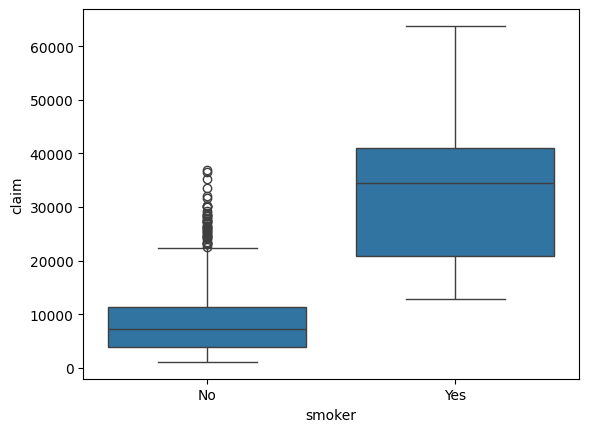

In [3]:
display(insurance.describe())

sns.boxplot(x='smoker', y='claim', data=insurance)
plt.show()

The boxplot reveals a large difference in claim amounts between smokers and non-smokers.

Step 2 – Handle missing values

In [4]:
display(insurance.isna().sum())

# Write code to fill in missing values
insurance['age'] = insurance['age'].fillna(insurance['age'].mean())
insurance['bmi'] = insurance['bmi'].fillna(insurance['bmi'].mean())
insurance['children'] = insurance['children'].fillna(insurance['children'].mean())
insurance['region'] = insurance['region'].fillna(insurance['region'].mode()[0])
insurance['bloodpressure'] = insurance['bloodpressure'].fillna(insurance['bloodpressure'].mean())

index             0
PatientID         0
age               5
gender            0
bmi               6
bloodpressure    11
diabetic          0
children          1
smoker            0
region            3
claim             0
dtype: int64

Step 3 – Formulate the Hypothesis

 Whether smokers have higher insurance claim amounts than non-smokers. I expect smokers to have higher claim amounts because smoking is associated with more health risks, which may lead to higher medical costs.

Only One Test Framework:

**Test statistic:**  The test statistic is the difference in mean insurance claim amount between smokers and non-smokers.

**Null hypothesis:**  There is no real difference in insurance claim amounts between smokers and non-smokers. Any observed difference in median claim amount is due to random chance.

**Alternative hypothesis:**  Smokers have higher insurance claim amounts than non-smokers.

In [5]:
# Define function for test statistic
def claim_diff(data):
    smoker_claim = data[data['smoker'] == 'Yes']['claim']
    nonsmoker_claim = data[data['smoker'] == 'No']['claim']
    return smoker_claim.mean() - nonsmoker_claim.mean()

observed_diff = claim_diff(insurance)
print(f"Observed difference in mean claim: {observed_diff:.2f}")

Observed difference in mean claim: 23629.11


In [6]:
# Permutation test
replicates = [observed_diff]
num_sim = 1000
smoker_sim = insurance["smoker"].tolist()

for _ in range(num_sim - 1):
    np.random.shuffle(smoker_sim)
    insurance_replicate = insurance.copy()
    insurance_replicate["smoker"] = smoker_sim
    replicates.append(claim_diff(insurance_replicate))

replicates = pd.DataFrame({"replicates": replicates})

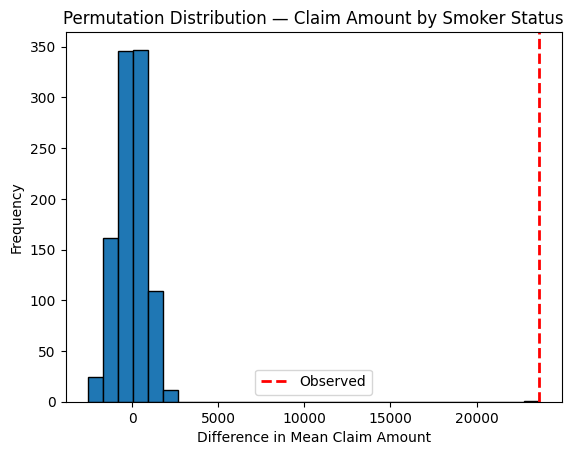

In [7]:
# Plot permutation distribution
plt.hist(replicates["replicates"], bins=30, edgecolor="black")
plt.axvline(observed_diff, color="red", linestyle="--", linewidth=2, label="Observed")
plt.xlabel("Difference in Mean Claim Amount")
plt.ylabel("Frequency")
plt.title("Permutation Distribution — Claim Amount by Smoker Status")
plt.legend()
plt.show()

In [8]:
# Calculate p-value
p_value = np.mean(abs(replicates["replicates"]) >= abs(observed_diff))
print(f"p-value: {p_value:.3f}")

p-value: 0.001


The observed difference in mean claim amount is about 23,629, which is far to the right of the permutation distribution. This means the observed difference is much larger than what would usually occur by random chance.

Because the p-value is very small, I will reject the null hypothesis. The results provide evidence that smokers tend to have higher insurance claim amounts than non-smokers in this dataset.

Step 4 – Bootstrap for uncertainty metric 

**Metric 1: Difference in median insurance claim amount between smokers and non-smokers.**

This metric does not rely on the CLT because the median is not a mean or proportion. 

**Metric 2: Difference in mean insurance claim amount between smokers and non-smokers.**

For bootstrapping, I will resample rows from the dataset with replacement. 
For each bootstrap sample, I will recalculate the metric. After repeating this process 1,000 times, I will use the 2.5th and 97.5th percentiles of the bootstrap results as a 95% confidence interval.

In [9]:
num_bootstrap = 1000

median_diffs = []
mean_diffs = []

for _ in range(num_bootstrap):
    bootstrap_sample = insurance.sample(frac=1, replace=True)

    smoker_claim = bootstrap_sample[bootstrap_sample["smoker"] == "Yes"]["claim"]
    nonsmoker_claim = bootstrap_sample[bootstrap_sample["smoker"] == "No"]["claim"]
    
    median_diff = smoker_claim.median() - nonsmoker_claim.median()
    mean_diff = smoker_claim.mean() - nonsmoker_claim.mean()
    
    median_diffs.append(median_diff)
    mean_diffs.append(mean_diff)

bootstrap_results = pd.DataFrame({
    "median_diff": median_diffs,
    "mean_diff": mean_diffs
})

bootstrap_results

,median_diff,mean_diff
0,26768.080,23197.912255
1,26662.860,22668.947481
2,27694.010,23940.558956
3,26923.310,23432.967168
4,27241.885,24160.525624
...,...,...
995,27021.340,23820.849471
996,22091.340,22545.200894
997,27257.975,24101.871371
998,27255.090,24118.893092


In [10]:
median_ci = bootstrap_results["median_diff"].quantile([0.025, 0.975])
mean_ci = bootstrap_results["mean_diff"].quantile([0.025, 0.975])

print("95% Bootstrap CI for median claim difference:")
print(median_ci)

print("\n95% Bootstrap CI for mean claim difference:")
print(mean_ci)

95% Bootstrap CI for median claim difference:
0.025    22156.59825
0.975    28919.90775
Name: median_diff, dtype: float64

95% Bootstrap CI for mean claim difference:
0.025    22321.032688
0.975    25080.299208
Name: mean_diff, dtype: float64


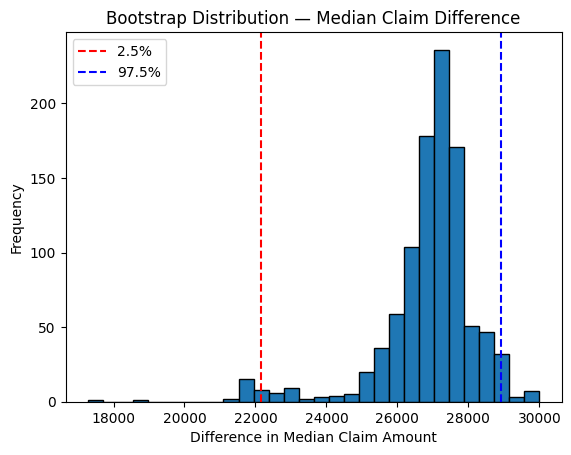

In [11]:
plt.hist(bootstrap_results["median_diff"], bins=30, edgecolor="black")
plt.axvline(bootstrap_results["median_diff"].quantile(0.025), color="red", linestyle="--", label="2.5%")
plt.axvline(bootstrap_results["median_diff"].quantile(0.975), color="blue", linestyle="--", label="97.5%")
plt.xlabel("Difference in Median Claim Amount")
plt.ylabel("Frequency")
plt.title("Bootstrap Distribution — Median Claim Difference")
plt.legend()
plt.show()

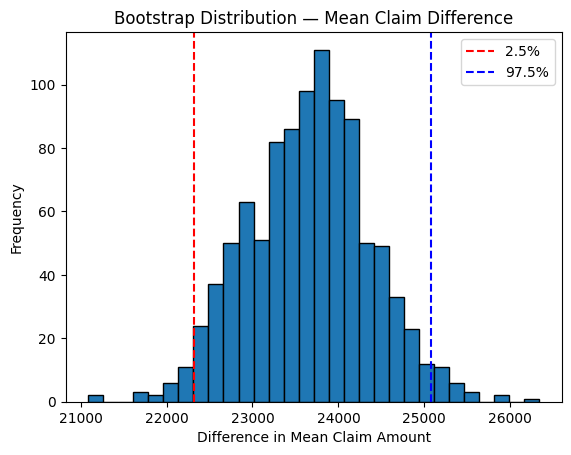

In [12]:
plt.hist(bootstrap_results["mean_diff"], bins=30, edgecolor="black")
plt.axvline(bootstrap_results["mean_diff"].quantile(0.025), color="red", linestyle="--", label="2.5%")
plt.axvline(bootstrap_results["mean_diff"].quantile(0.975), color="blue", linestyle="--", label="97.5%")
plt.xlabel("Difference in Mean Claim Amount")
plt.ylabel("Frequency")
plt.title("Bootstrap Distribution — Mean Claim Difference")
plt.legend()
plt.show()

To estimate uncertainty, I used bootstrap confidence intervals for the median and mean claim differences between smokers and non-smokers.

The 95% bootstrap CI for the median difference is about 22,284 to 28,928, and the 95% bootstrap CI for the mean difference is about 22,245 to 25,029. Since both intervals are fully above 0, the results support that smokers tend to have higher insurance claim amounts than non-smokers.

Step 5 - Interpret result

**What question did you ask?**

Whether smokers have higher insurance claim amounts than non-smokers. 

**What data did you use?**

I used the insurance dataset, which includes 1,340 patients. The main variables I used were smoker status and insurance claim amount.

**What patterns or relationships did you find?**

The boxplot showed that smokers generally had much higher claim amounts than non-smokers. The observed mean claim difference was about 23,629, with smokers having higher claims.

**How certain are you about those results?**

The permutation test gave a very small p-value of 0.001, so the result is unlikely to be due to random chance. The bootstrap confidence intervals were also fully above 0, which supports the conclusion.

**What would you recommend or conclude?**

I conclude that smokers in this dataset tend to have higher insurance claim amounts than non-smokers. This suggests that smoking status is an important factor to consider when analyzing or predicting insurance claim costs.